In [10]:
%pip install pandas numpy scikit-learn matplotlib seaborn joblib flask flask-cors

In [11]:
def calculate_average_percent(scores: list, max_marks: list) -> float:

    if len(scores) != len(max_marks):
        raise ValueError('scores and max_marks must have the same length')
    if len(scores) == 0:
        raise ValueError('At least one score is required')

    percentages = [(s / m) * 100 for s, m in zip(scores, max_marks)]
    return round(sum(percentages) / len(percentages), 2)


def calculate_attendance_percent(attended: int, total: int) -> float:
    
    if total <= 0:
        raise ValueError('Total classes must be greater than 0')
    return round((attended / total) * 100, 2)


def prepare_student_features(raw_input: dict) -> dict:
  
    return {
        'quiz_avg':       calculate_average_percent(
                              raw_input['quiz_scores'], raw_input['quiz_max']),
        'assignment_avg': calculate_average_percent(
                              raw_input['assignment_scores'], raw_input['assignment_max']),
        'exam_avg':       calculate_average_percent(
                              raw_input['exam_scores'], raw_input['exam_max']),
        'attendance_pct': calculate_attendance_percent(
                              raw_input['classes_attended'], raw_input['total_classes'])
    }


sample_input = {
    'quiz_scores':       [16, 14, 18],
    'quiz_max':          [20, 20, 20],
    'assignment_scores': [28, 35],
    'assignment_max':    [40, 40],
    'exam_scores':       [55, 62],
    'exam_max':          [100, 100],
    'classes_attended':  18,
    'total_classes':     24
}

features = prepare_student_features(sample_input)
print('Computed features:')
for key, val in features.items():
    print(f'  {key:<18} {val}%')

Computed features:
  quiz_avg           80.0%
  assignment_avg     78.75%
  exam_avg           58.5%
  attendance_pct     75.0%


In [12]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 500

quiz_avg       = np.round(np.random.uniform(20, 100, n), 1)
assignment_avg = np.round(np.random.uniform(20, 100, n), 1)
exam_avg       = np.round(np.random.uniform(20, 100, n), 1)
attendance_pct = np.round(np.random.uniform(30, 100, n), 1)

df = pd.DataFrame({
    'quiz_avg':       quiz_avg,
    'assignment_avg': assignment_avg,
    'exam_avg':       exam_avg,
    'attendance_pct': attendance_pct
})

def assign_risk(row):
    score = 0
    if row['attendance_pct'] < 60:  score += 3
    elif row['attendance_pct'] < 75: score += 1

    if row['exam_avg'] < 40:   score += 3
    elif row['exam_avg'] < 55: score += 2
    elif row['exam_avg'] < 65: score += 1

    if row['quiz_avg'] < 40:   score += 2
    elif row['quiz_avg'] < 55: score += 1

    if row['assignment_avg'] < 40:   score += 2
    elif row['assignment_avg'] < 55: score += 1

    if score >= 6:   return 'high'
    elif score >= 3: return 'medium'
    else:            return 'low'

df['risk_level'] = df.apply(assign_risk, axis=1)

df.to_csv('students.csv', index=False)

print(f'Dataset: {df.shape[0]} students, {df.shape[1]} columns')
print()
print('Risk distribution:')
print(df['risk_level'].value_counts())
print()
df.head(8)

Dataset: 500 students, 5 columns

Risk distribution:
risk_level
medium    255
high      129
low       116
Name: count, dtype: int64



,quiz_avg,assignment_avg,exam_avg,attendance_pct,risk_level
0,50.0,75.9,34.8,66.3,medium
1,96.1,62.9,63.4,63.5,low
2,78.6,44.8,89.8,31.8,medium
3,67.9,85.1,78.6,53.9,medium
4,32.5,74.8,84.5,56.6,medium
5,32.5,33.0,72.7,57.9,high
6,24.6,92.9,75.4,70.6,medium
7,89.3,85.8,87.9,67.4,low


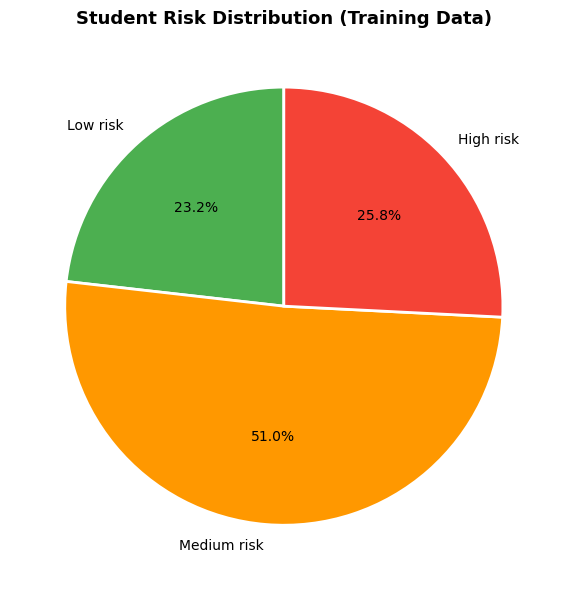

In [13]:
import matplotlib.pyplot as plt

counts = df['risk_level'].value_counts()

order  = ['low', 'medium', 'high']
counts = counts.reindex(order)
colors = ['#4CAF50', '#FF9800', '#F44336']

plt.figure(figsize=(6, 6))
plt.pie(
    counts,
    labels=[f'{l.capitalize()} risk' for l in order],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
plt.title('Student Risk Distribution (Training Data)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report

feature_cols = ['quiz_avg', 'assignment_avg', 'exam_avg', 'attendance_pct']

X = df[feature_cols]
y = df['risk_level']

le = LabelEncoder()
y_encoded = le.fit_transform(y)
print('Label encoding:', dict(zip(le.classes_, le.transform(le.classes_))))

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

preds    = rf.predict(X_test)
accuracy = accuracy_score(y_test, preds)

print(f'\nAccuracy: {accuracy*100:.1f}%')
print()
print(classification_report(y_test, preds, target_names=le.classes_))

Label encoding: {'high': np.int64(0), 'low': np.int64(1), 'medium': np.int64(2)}

Accuracy: 92.0%

              precision    recall  f1-score   support

        high       0.88      0.88      0.88        26
         low       0.96      0.96      0.96        23
      medium       0.92      0.92      0.92        51

    accuracy                           0.92       100
   macro avg       0.92      0.92      0.92       100
weighted avg       0.92      0.92      0.92       100



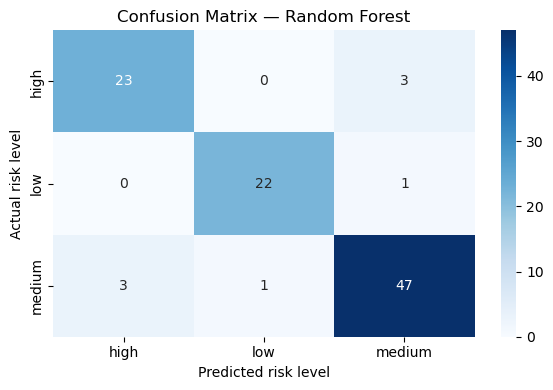

Diagonal = correct predictions


In [15]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title('Confusion Matrix — Random Forest')
plt.ylabel('Actual risk level')
plt.xlabel('Predicted risk level')
plt.tight_layout()
plt.show()
print('Diagonal = correct predictions')

In [16]:
import joblib, os

os.makedirs('models', exist_ok=True)

joblib.dump(rf,     'models/risk_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(le,     'models/label_encoder.pkl')

print('Saved: models/risk_model.pkl')
print('Saved: models/scaler.pkl')
print('Saved: models/label_encoder.pkl')

Saved: models/risk_model.pkl
Saved: models/scaler.pkl
Saved: models/label_encoder.pkl


In [17]:
import joblib
import numpy as np

_model   = joblib.load('models/risk_model.pkl')
_scaler  = joblib.load('models/scaler.pkl')
_encoder = joblib.load('models/label_encoder.pkl')


def get_risk_reason(features: dict) -> str:
   
    thresholds = {
        'quiz_avg':       ('Quiz average is low',       55),
        'assignment_avg': ('Assignment average is low',  55),
        'exam_avg':       ('Exam average is low',        55),
        'attendance_pct': ('Attendance is below 75%',    75),
    }

   
    failing = []
    for key, (label, threshold) in thresholds.items():
        if features[key] < threshold:
            failing.append((label, threshold - features[key]))

    if not failing:
        return 'All areas are performing well'


    failing.sort(key=lambda x: x[1], reverse=True)
    return failing[0][0]


def predict_risk(raw_input: dict) -> dict:
    
    computed = prepare_student_features(raw_input)

    features = np.array([[
        computed['quiz_avg'],
        computed['assignment_avg'],
        computed['exam_avg'],
        computed['attendance_pct']
    ]])

    scaled      = _scaler.transform(features)
    pred        = _model.predict(scaled)[0]
    proba       = _model.predict_proba(scaled)[0]
    risk_label  = _encoder.inverse_transform([pred])[0]
    confidence  = round(float(max(proba)) * 100, 1)

    reason = get_risk_reason(computed)

    return {
        'risk_level': risk_label,
        'confidence': f'{confidence}%',
        'reason':     reason,
        'computed':   computed
    }


struggling = {
    'quiz_scores':       [8, 6, 7],
    'quiz_max':          [20, 20, 20],
    'assignment_scores': [12, 15],
    'assignment_max':    [40, 40],
    'exam_scores':       [32, 28],
    'exam_max':          [100, 100],
    'classes_attended':  14,
    'total_classes':     30
}

strong = {
    'quiz_scores':       [18, 17, 19],
    'quiz_max':          [20, 20, 20],
    'assignment_scores': [36, 38],
    'assignment_max':    [40, 40],
    'exam_scores':       [85, 90],
    'exam_max':          [100, 100],
    'classes_attended':  27,
    'total_classes':     30
}

low_attendance = {
    'quiz_scores':       [16, 15],
    'quiz_max':          [20, 20],
    'assignment_scores': [32, 35, 30],
    'assignment_max':    [40, 40, 40],
    'exam_scores':       [72],
    'exam_max':          [100],
    'classes_attended':  10,
    'total_classes':     30
}

print('── Struggling student ──')
result = predict_risk(struggling)
print(f"  Risk       : {result['risk_level'].upper()}")
print(f"  Confidence : {result['confidence']}")
print(f"  Reason     : {result['reason']}")
print(f"  Computed   : {result['computed']}")

print()
print('── Strong student ──')
result = predict_risk(strong)
print(f"  Risk       : {result['risk_level'].upper()}")
print(f"  Confidence : {result['confidence']}")
print(f"  Reason     : {result['reason']}")
print(f"  Computed   : {result['computed']}")

print()
print('── Good marks, low attendance ──')
result = predict_risk(low_attendance)
print(f"  Risk       : {result['risk_level'].upper()}")
print(f"  Confidence : {result['confidence']}")
print(f"  Reason     : {result['reason']}")
print(f"  Computed   : {result['computed']}")

── Struggling student ──
  Risk       : HIGH
  Confidence : 100.0%
  Reason     : Attendance is below 75%
  Computed   : {'quiz_avg': 35.0, 'assignment_avg': 33.75, 'exam_avg': 30.0, 'attendance_pct': 46.67}

── Strong student ──
  Risk       : LOW
  Confidence : 100.0%
  Reason     : All areas are performing well
  Computed   : {'quiz_avg': 90.0, 'assignment_avg': 92.5, 'exam_avg': 87.5, 'attendance_pct': 90.0}

── Good marks, low attendance ──
  Risk       : MEDIUM
  Confidence : 99.0%
  Reason     : Attendance is below 75%
  Computed   : {'quiz_avg': 77.5, 'assignment_avg': 80.83, 'exam_avg': 72.0, 'attendance_pct': 33.33}


c:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
